In [1]:
import numpy as np
from matplotlib import pyplot as plt

from s3topologies import LensSpace

To initialize an instance of a Lens Space, we can specify the following parameters:

- ``OmegaK`` : Curvature density parameter $\Omega_K$. Has to be negative. Default is $-10^{-3}$ 
- ``lmax`` : Maximum multipole $\ell$ to include in the analysis ($\ell_{min}$ for now is necessarily 2)
- ``compute_kmax_internally`` : If True, it will compute the kmax up to which one has to sum to achieve the given accuracy of $C_\ell$'s. Defaults to False.
- ``compute_kmax_tol`` : Parameter to specify degree of convergence with respect to $S^3$ $C_{\ell}$'s. Default is 0.005, which means the diagonal of $C_{\ell m\ell\prime m\prime}$ is at least 99.5% of $C_{\ell}$'s
- ``kmax`` : If ``compute_kmax_internally`` is False, one can manually specify $k_{max}$. Defaults to $10^{-3}$.
- ``p`` : Integer specifying the Lens Space. Defaults to 5.
- ``q`` : Integer specifying the Lens Space. Defaults to 2.   
(Remember that $1\leq q\leq p$ and $p$ and $q$ have to be coprime. $L(1,1)$ is the same as the covering space $S^3$, $L(2,1)$ is the isotropic Elliptic space and all Lens Spaces of the form $L(p,1)$ are homogeneous.)
- ``obs_ang`` : similar to $(x_0,y_0,z_0)$ in the Euclidean setting, it is the origin with respect to which the topology defining generators are defined. It is specified by the three toroidal angles $(\theta_0,\chi_0,\varphi_0)$. As in the Euclidean case there are only two DOF really: $\chi_0$ and $\theta_0-\varphi_0$. The one that matters most is $\chi_0$ and in some sense is the distance to one of the two main axis. When $\chi_0=0$ the observer lies on one of the great circles defining the Lens spaces, and as $\chi_0\rightarrow\pi/2$ the observer sits on the other great circle. 

There are other arguments related to hardware:

- ``num_workers`` : The main sum to compute $C_{\ell m\ell\prime m\prime}$ is parallelized. This parameter specifies across how many CPUs that sum is parallelized. The default setting is that it will use halg the available CPUs. Each CPU gets ``total_avail_CPUs // num_workers`` to do the math.
- ``batchsize`` : The principal sum in $n$ is split into balanced chunks of size ``batchsize``, and so each worker computes the contribution of that chunk of $n$'s at a time. By default it is set to ``(nmax-2)// num_workers`` (recommended). Setting it to a smaller value (e.g. 10 or 30) is only useful to keep track of progress with the progress bar.
- ``use_tqdm`` : If True, the progress in the computation of $C_{\ell m\ell\prime m\prime}$ is neatly represented by a ``tqdm`` bar (recommended when running locally/laptop). Default is False, as most SLURM managed clusters are not tqdm friendly. It will instead show alternative, simpler progress messages.

In [7]:
lens_params = {
    'OmegaK' : -5e-2,
    'lmax': 8,
    'compute_kmax_internally': True,
    'compute_kmax_tol' : 0.005,
    'p' : 5,
    'q' : 2,
    'obs_ang' : [0.1,0.0,0.3],
    'num_workers': 8,
    'batchsize': 10,
    'use_tqdm': True,
}

lens = LensSpace(lens_params)

Looking for optimum kmax for the given ell_max...
Convergence reached. kmax is 1.6756e-02. This kmax will compute the Cls with an accuracy of 99.52%.


In [8]:
lens.compute_Clmlpmp_optimized()

Clmlpmp computation started. nmax is 332
Distributing sum in n across 8 parallel CPU cores...


Computing batches: 100%|██████████| 33/33 [00:00<00:00, 175.68it/s, n_processed=331/331]

Time taken: 2.74s


/home/mikel/Desktop/S3/s3topologies.py:594: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(self.norm_C_matrix)),cmap=cmap,vmin=-8,origin='lower')


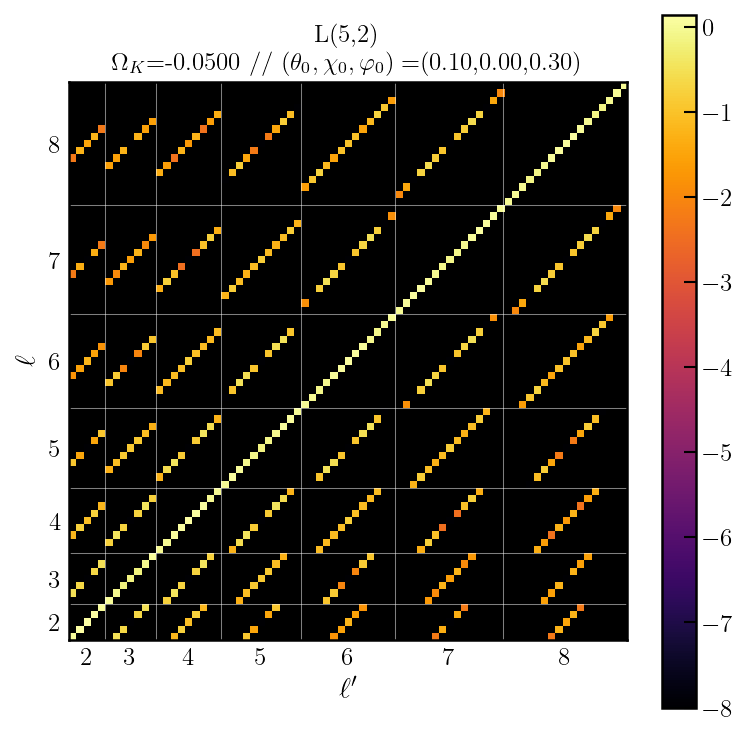

In [9]:
lens.plot_Clmlpmp()

In [10]:
# Forward KL first, Backward KL second
lens.compute_KL()

array([5.07065838, 8.08232264])